##Dataset Preparation

In [ ]:
pip install transformers>=4.51.0

In [ ]:
# to access Qwen3-4B's token vocabulary
from transformers import AutoTokenizer

In [ ]:
# load tokenizer
model_name = "Qwen/Qwen3-4B"
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
# check
vocabulary = tokenizer.get_vocab()
list(vocabulary.items())[:10]

[('Ġragazze', 47599),
 ('Ð¿ÑĢÐµÑģÑģ', 133228),
 ('èĤ¡ä¸ľ', 100800),
 ('ĠFrontier', 57318),
 ('ð¬¹', 122999),
 ('Ġbat', 15743),
 ('.l', 918),
 ('Vict', 36125),
 ('ĠCOM', 7682),
 ('(valid', 41529)]

In [ ]:
# closed compounds are compounds consisting of one word (airport)
# hyphenated (able-bodied) or open (night shift) compounds were outside the scope of this research
closed_compounds = []

In [ ]:
# function to find closed compounds
def filter_compounds(compounds):
  for word in compounds:
    if ' ' in word or '-' in word:
      continue
    else:
      closed_compounds.append(word)
  return closed_compounds

In [ ]:
# load preprocessed dataset of 1720 compounds obtained from https://www.proofreadingservices.com/pages/compound-words-list
with open("compounds.txt", "r", encoding="utf-8") as f:
    compounds = [line.strip() for line in f if line.strip()]
print(len(compounds))
print(compounds[:10])

1720
['able-bodied', 'flowerpot', 'nevertheless', 'snowfall', 'aftereffect', 'flyby', 'newborn', 'snowflake', 'afternoon', 'flyweight']


In [ ]:
# filter closed compounds
closed_compounds = filter_compounds(compounds)
print(len(closed_compounds))
print(closed_compounds[:10])

1566
['flowerpot', 'nevertheless', 'snowfall', 'aftereffect', 'flyby', 'newborn', 'snowflake', 'afternoon', 'flyweight', 'newcomer']


In [ ]:
# create lists of compounds represented with a single token or multiple tokens
single_token_compounds = []
multi_token_compounds = []

In [ ]:
# distribute compounds into two groups based on the tokenization pattern
def check_tokenization(compounds, single_token_list, multi_token_list):
  for word in compounds:
    tokens = tokenizer.tokenize(word)
    if len(tokens) == 1:
      single_token_list.append(word)
    else:
      multi_token_list.append(word)
  return (single_token_list, multi_token_list)

In [ ]:
# distribute compounds into groups
single_token_compounds, multi_token_compounds = check_tokenization(closed_compounds, single_token_compounds, multi_token_compounds)
print(len(single_token_compounds))
print(single_token_compounds[:10])

print(len(multi_token_compounds))
print(multi_token_compounds[:10])

83
['newsletter', 'airport', 'football', 'software', 'another', 'someone', 'something', 'anything', 'forecast', 'nothing']
1483
['flowerpot', 'nevertheless', 'snowfall', 'aftereffect', 'flyby', 'newborn', 'snowflake', 'afternoon', 'flyweight', 'newcomer']


In [ ]:
whitespace_compounds = []

In [ ]:
# create token versions with leading whitespace
def add_leading_whitespace(compounds, whitespace_compounds):
  for word in compounds:
    whitespace_compounds.append(' ' + word)
  return whitespace_compounds

In [ ]:
# divide compounds with leading whitespace into two groups
whitespace_compounds = add_leading_whitespace(closed_compounds, whitespace_compounds)
print(len(whitespace_compounds))
print(whitespace_compounds[:10])

1566
[' flowerpot', ' nevertheless', ' snowfall', ' aftereffect', ' flyby', ' newborn', ' snowflake', ' afternoon', ' flyweight', ' newcomer']


In [ ]:
whitespace_single_token_compounds = []
whitespace_multi_token_compounds = []

In [ ]:
whitespace_single_token_compounds, whitespace_multi_token_compounds = check_tokenization(whitespace_compounds, whitespace_single_token_compounds, whitespace_multi_token_compounds)

In [ ]:
print(len(whitespace_single_token_compounds))
print(whitespace_single_token_compounds[:10])

472
[' nevertheless', ' newborn', ' afternoon', ' newcomer', ' newsletter', ' newspaper', ' aircraft', ' folklore', ' airline', ' airplane']


In [ ]:
print(len(whitespace_multi_token_compounds))
print(whitespace_multi_token_compounds[:10])

1094
[' flowerpot', ' snowfall', ' aftereffect', ' flyby', ' snowflake', ' flyweight', ' snowman', ' afterthought', ' flywheel', ' snowplow']


In [ ]:
single_token_compounds_removed = []
multi_token_compounds_removed = []

In [ ]:
# remove whitespace to compare compound lists
def remove_whitespace (compounds, removed):
  for token in compounds:
    token = token.lstrip()
    removed.append(token)
  return removed

In [ ]:
single_token_compounds_removed = remove_whitespace(whitespace_single_token_compounds, single_token_compounds_removed)
print(len(single_token_compounds_removed))
print(single_token_compounds_removed[:10])

472
['nevertheless', 'newborn', 'afternoon', 'newcomer', 'newsletter', 'newspaper', 'aircraft', 'folklore', 'airline', 'airplane']


In [ ]:
multi_token_compounds_removed = remove_whitespace(whitespace_multi_token_compounds, multi_token_compounds_removed)
print(len(multi_token_compounds_removed))
print(multi_token_compounds_removed[:10])

1094
['flowerpot', 'snowfall', 'aftereffect', 'flyby', 'snowflake', 'flyweight', 'snowman', 'afterthought', 'flywheel', 'snowplow']


In [ ]:
# compare lists pairwise to find compounds with stable and unstable tokenisation:
# - true single token compounds = compounds both in single token and whitespace single token groups
# - conditional single token compounds = compounds in whitespace single token group but not in single token group
# - true multi-token compounds = compounds both in multi-token and whitespace multi token group

true_single_token_compounds = []
conditional_single_token_compounds = []
true_multi_token_compounds = []

In [ ]:
# function to find compounds with stable tokenisation
def true_compounds(compounds1, compounds2, true_compounds):
    for token in compounds1:
        if token in compounds2:
            true_compounds.append(token)
    return true_compounds

In [ ]:
# find single token compounds with stable tokenization
true_single_token_compounds = true_compounds(single_token_compounds, single_token_compounds_removed, true_single_token_compounds)
print(len(true_single_token_compounds))
print(true_single_token_compounds[:10])

82
['newsletter', 'airport', 'football', 'software', 'another', 'someone', 'something', 'anything', 'forecast', 'nothing']


In [ ]:
# check
tokens = tokenizer.tokenize('popover')
print(tokens)
tokens = tokenizer.tokenize(' popover')
print(tokens)

['popover']
['Ġpopover']


In [ ]:
# find single token compounds with stable tokenization
true_multi_token_compounds = true_compounds(multi_token_compounds, multi_token_compounds_removed, true_multi_token_compounds)
print(len(true_multi_token_compounds))
print(true_multi_token_compounds[:10])

1093
['flowerpot', 'snowfall', 'aftereffect', 'flyby', 'snowflake', 'flyweight', 'snowman', 'afterthought', 'flywheel', 'snowplow']


In [ ]:
# check
tokens = tokenizer.tokenize('aftereffect')
print(tokens)
tokens = tokenizer.tokenize(' aftereffect')
print(tokens)

['after', 'effect']
['Ġafter', 'effect']


In [ ]:
import numpy as np

In [ ]:
# finds compounds with unstable tokenization (depending on the leading whitespace)
def conditional_compounds (compounds1, compounds2, conditional_compounds):
  conditional_compounds = list(set(compounds1) - set(compounds2))
  return conditional_compounds

In [ ]:
conditional_single_token_compounds = conditional_compounds(single_token_compounds_removed, single_token_compounds, conditional_single_token_compounds)
print(len(conditional_single_token_compounds))
print(conditional_single_token_compounds[:10])

390
['lawsuit', 'waterfall', 'hindsight', 'overpower', 'salesman', 'farewell', 'roadway', 'understand', 'downhill', 'countryside']


In [ ]:
# add leading whitespace back to each token

whitespace_true_single_token_compounds = []
whitespace_conditional_single_token_compounds = []
whitespace_true_multi_token_compounds = []

In [ ]:
whitespace_true_single_token_compounds = add_leading_whitespace(true_single_token_compounds, whitespace_true_single_token_compounds)
print(len(whitespace_true_single_token_compounds))
print(whitespace_true_single_token_compounds[:10])

82
[' newsletter', ' airport', ' football', ' software', ' another', ' someone', ' something', ' anything', ' forecast', ' nothing']


In [ ]:
whitespace_true_multi_token_compounds = add_leading_whitespace(true_multi_token_compounds, whitespace_true_multi_token_compounds)
print(len(whitespace_true_multi_token_compounds))
print(whitespace_true_multi_token_compounds[:10])

1093
[' flowerpot', ' snowfall', ' aftereffect', ' flyby', ' snowflake', ' flyweight', ' snowman', ' afterthought', ' flywheel', ' snowplow']


In [ ]:
conditional_single_token_compounds_blank_space = add_leading_whitespace(conditional_single_token_compounds, whitespace_conditional_single_token_compounds)
print(len(whitespace_conditional_single_token_compounds))
print(whitespace_conditional_single_token_compounds[:10])

390
[' lawsuit', ' waterfall', ' hindsight', ' overpower', ' salesman', ' farewell', ' roadway', ' understand', ' downhill', ' countryside']


## Measuring Activations

In [ ]:
# mechanistic interpretability library: adds hooks to transformers for accessing internal activations
!pip install transformer_lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 51.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 126.0 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=6a16a511bafaabb93299316a3a9441f97082330c31af80010b99fdeb7641326c
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: beartype
    Found existing install

In [ ]:
# provides Zipf frequency scores for words
!pip install wordfreq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.1/183.1 kB 19.2 MB/s eta 0:00:00


In [ ]:
import torch
from transformer_lens import HookedTransformer # enables extracting Layer 0 activations for transcoder analysis
from huggingface_hub import hf_hub_download # fetches transcoder weights from mwhanna/qwen3-4b-transcoders
import safetensors.torch #  loads transcoder weights from .safetensors files
from scipy import stats
import matplotlib.pyplot as plt
from wordfreq import zipf_frequency # gives zipf frequency scores for words in English

In [ ]:
# load Qwen3-4B with TransformerLens
model_name = 'Qwen/Qwen3-4B'
model = HookedTransformer.from_pretrained(
    model_name,
    dtype=torch.bfloat16,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/99.6M [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded pretrained model Qwen/Qwen3-4B into HookedTransformer


In [ ]:
# load transcoder for layer 0
transcoder_name = "mwhanna/qwen3-4b-transcoders"
transcoder_path = hf_hub_download(
    repo_id=transcoder_name,
    filename="layer_0.safetensors"
)

layer_0.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

In [ ]:
# transcoder is a model that decomposes dense Layer 0 activations into interpretable sparse features
# it takes dense 2048-dimension L0 output and transforms them into sparse ~16k feature space

# load transcoder weights
transcoder_weights = safetensors.torch.load_file(transcoder_path)
print(f"Keys: {list(transcoder_weights.keys())}")

# create the SimpleTranscoder class
class SimpleTranscoder:
    def __init__(self, weights, device='cuda'):
        # get the dtype from the weights (should be bfloat16)
        self.dtype = weights['W_enc'].dtype
        self.W_enc = weights['W_enc'].to(device)
        self.W_dec = weights['W_dec'].to(device)
        self.b_enc = weights['b_enc'].to(device)
        self.b_dec = weights['b_dec'].to(device)

    def encode(self, x):
        # encode MLP output to feature activations
        # convert input to same dtype as transcoder weights
        x = x.to(self.dtype)

        # x shape: [batch, seq_len, d_model]
        # W_enc shape: [num_features, d_model] = [163840, 2560]
        # we need: x @ W_enc.T = [batch, seq_len, d_model] @ [d_model, num_features]
        features = torch.nn.functional.relu(x @ self.W_enc.T + self.b_enc)
        return features

# recreate the transcoder with the fixed class
device = 'cuda' if torch.cuda.is_available() else 'cpu'
transcoder = SimpleTranscoder(transcoder_weights, device=device)
print(f"  Transcoder dtype: {transcoder.dtype}") # should be bfloat16

Keys: ['W_dec', 'W_enc', 'b_dec', 'b_enc']
  Transcoder dtype: torch.bfloat16


In [ ]:
# measure 118230/L0 activations for a list of whitespace compounds
# for multi-token compounds, return the activation value for the last token because it incorporates contextual information from previous tokens
# return a dictionary where the key is the word, and value is the activation value

def measure_activations(compounds, layer=0, feature_index=118230):
    # initialize empty dictionary to store results
    activations = {}

    # loop through the list of tokens
    for compound in compounds:
        # tokenize the prompt and move to device (GPU/CPU)
        input_ids = model.tokenizer(compound, return_tensors="pt")['input_ids'].to(model.cfg.device)

        # run the model and cache all intermediate activations
        _, cache = model.run_with_cache(input_ids)

        # extract MLP input activations (layer norm output before MLP)
        mlp_input = cache[f"blocks.{layer}.ln2.hook_normalized"]

        # apply the transcoder encoder to get feature activations
        with torch.no_grad():
            # use manually loaded transcoder
            feature_activations = transcoder.encode(mlp_input)

            # get activation at last token position
            activation = feature_activations[0, -1, feature_index].cpu().item()

        # store the activation value in the dictionary
        activations[compound] = activation

    # return the results in dictionary format
    return activations

In [ ]:
activations_true_single_token_compounds = measure_activations(whitespace_true_single_token_compounds, layer=0, feature_index=118230)
print(len(activations_true_single_token_compounds))
print(list(activations_true_single_token_compounds.items())[:10])

82
[(' newsletter', 6.5), (' airport', 0.0), (' football', 0.0), (' software', 0.0), (' another', 0.0), (' someone', 0.0), (' something', 0.0), (' anything', 0.0), (' forecast', 0.0), (' nothing', 0.0)]


In [ ]:
activations_conditional_single_token_compounds = measure_activations(whitespace_conditional_single_token_compounds, layer=0, feature_index=118230)
print(len(activations_conditional_single_token_compounds))
print(list(activations_conditional_single_token_compounds.items())[:10])

390
[(' lawsuit', 6.4375), (' waterfall', 14.75), (' hindsight', 6.4375), (' overpower', 0.0), (' salesman', 1.1484375), (' farewell', 5.6875), (' roadway', 0.0), (' understand', 0.0), (' downhill', 3.328125), (' countryside', 0.0)]


In [ ]:
activations_true_multi_token_compounds = measure_activations(whitespace_true_multi_token_compounds, layer=0, feature_index=118230)
print(len(activations_true_multi_token_compounds))
print(list(activations_true_multi_token_compounds.items())[:10])

1093
[(' flowerpot', 0.0), (' snowfall', 0.0), (' aftereffect', 0.0), (' flyby', 0.0), (' snowflake', 0.0), (' flyweight', 0.0), (' snowman', 0.0), (' afterthought', 0.0), (' flywheel', 0.0), (' snowplow', 0.0)]


In [ ]:
# calculate mean and standard deviation for each group

# extract activation values from each dictionary
true_single = list(activations_true_single_token_compounds.values())
conditional_single = list(activations_conditional_single_token_compounds.values())
true_multi = list(activations_true_multi_token_compounds.values())

# calculate averages
avg_true_single = np.mean(true_single)
avg_conditional_single = np.mean(conditional_single)
avg_true_multi = np.mean(true_multi)

# calculate standard deviations
std_true_single = np.std(true_single)
std_conditional_single = np.std(conditional_single)
std_multi = np.std(true_multi)

# print results
print(f"\nTrue Single Token Compounds (n={len(true_single)}):")
print(f"  Mean: {avg_true_single:.4f}")
print(f"  Std:  {std_true_single:.4f}")

print(f"\nConditional Single Token Compounds (n={len(conditional_single)}):")
print(f"  Mean: {avg_conditional_single:.4f}")
print(f"  Std:  {std_conditional_single:.4f}")

print(f"\nTrue Multi Token Compounds (n={len(true_multi)}):")
print(f"  Mean: {avg_true_multi:.4f}")
print(f"  Std:  {std_multi:.4f}")


True Single Token Compounds (n=82):
  Mean: 1.2202
  Std:  3.1757

Conditional Single Token Compounds (n=390):
  Mean: 6.1271
  Std:  5.5718

True Multi Token Compounds (n=1093):
  Mean: 0.0298
  Std:  0.4295


In [ ]:
# statistical comparison of groups

# conditional vs true single
t_stat_1, p_value_1 = stats.ttest_ind(conditional_single, true_single)
print(f"\n1. Conditional Single vs True Single Token:")
print(f"   t-statistic: {t_stat_1:.4f}")
print(f"   p-value: {p_value_1:.4e}")
print(f"   Significant at α=0.05: {'YES' if p_value_1 < 0.05 else 'NO'}")
print(f"   Effect: Conditional {'>' if t_stat_1 > 0 else '<'} True Single")

# conditional vs multi
t_stat_2, p_value_2 = stats.ttest_ind(conditional_single, true_multi)
print(f"\n2. Conditional Single vs True Multi-Token:")
print(f"   t-statistic: {t_stat_2:.4f}")
print(f"   p-value: {p_value_2:.4e}")
print(f"   Significant at α=0.05: {'YES' if p_value_2 < 0.05 else 'NO'}")
print(f"   Effect: Conditional {'>' if t_stat_2 > 0 else '<'} True Multi")

# true single vs multi
t_stat_3, p_value_3 = stats.ttest_ind(true_single, true_multi)
print(f"\n3. True Single vs True Multi-Token:")
print(f"   t-statistic: {t_stat_3:.4f}")
print(f"   p-value: {p_value_3:.4e}")
print(f"   Significant at α=0.05: {'YES' if p_value_3 < 0.05 else 'NO'}")
print(f"   Effect: True Single {'>' if t_stat_3 > 0 else '<'} True Multi")


1. Conditional Single vs True Single Token:
   t-statistic: 7.6991
   p-value: 8.1574e-14
   Significant at α=0.05: YES
   Effect: Conditional > True Single

2. Conditional Single vs True Multi-Token:
   t-statistic: 35.8569
   p-value: 3.1876e-203
   Significant at α=0.05: YES
   Effect: Conditional > True Multi

3. True Single vs True Multi-Token:
   t-statistic: 11.1031
   p-value: 2.6325e-27
   Significant at α=0.05: YES
   Effect: True Single > True Multi


/tmp/ipython-input-466104929.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data,


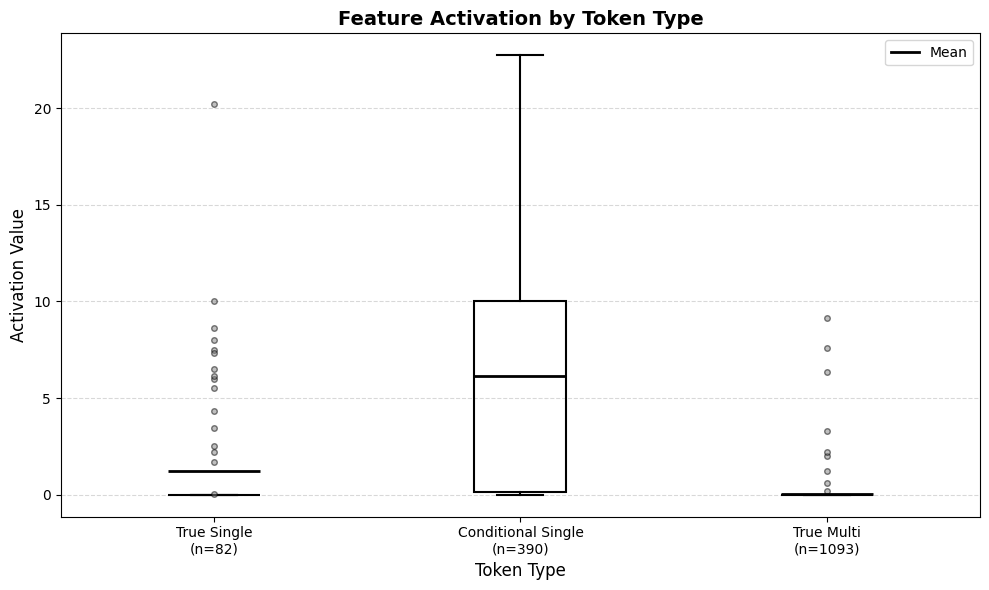

In [ ]:
# prepare data for boxplot

data = [true_single, conditional_single, true_multi]
labels = [
    f'True Single\n(n={len(true_single)})',
    f'Conditional Single\n(n={len(conditional_single)})',
    f'True Multi\n(n={len(true_multi)})'
]

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Create boxplot
bp = ax.boxplot(data,
                labels=labels,
                patch_artist=True,
                showmeans=True,
                showfliers=True,
                meanline=True,  # show mean as line
                meanprops=dict(color='black', linewidth=2, linestyle='-'),
                medianprops=dict(visible=False),  # hide median
                boxprops=dict(facecolor='none', edgecolor='black', linewidth=1.5),  # transparent fill, visible edges
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5),
                flierprops=dict(marker='o', markerfacecolor='gray', markersize=4,
                               linestyle='none', markeredgecolor='black', alpha=0.5))

# add title and labels
ax.set_title('Feature Activation by Token Type',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Activation Value', fontsize=12)
ax.set_xlabel('Token Type', fontsize=12)

# add grid for readability
ax.yaxis.grid(True, linestyle='--', alpha=0.3, color='gray')
ax.set_axisbelow(True)

# add legend
legend_elements = [
    plt.Line2D([0], [0], color='black', linewidth=2, label='Mean')
]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# function to analyse outliers

def print_outliers(activations_dict, group_name, threshold=0.001):
    print(f"OUTLIERS: {group_name}")

    # get all non-zero activations
    nonzero = {word: act for word, act in activations_dict.items() if act > 0}

    # sort by activation value (highest to lowest)
    sorted_outliers = sorted(nonzero.items(), key=lambda x: x[1], reverse=True)

    # statistics
    total = len(activations_dict)
    num_nonzero = len(sorted_outliers)
    percentage = 100 * num_nonzero / total if total > 0 else 0

    print(f"\n{num_nonzero} non-zero activations out of {total} total")
    print(f"Percentage: {percentage:.1f}%")

    avg_nonzero = sum(act for _, act in sorted_outliers) / num_nonzero
    max_activation = sorted_outliers[0][1]
    min_activation = sorted_outliers[-1][1]

    print(f"Range: {min_activation:.4f} to {max_activation:.4f}")
    print(f"\n{'Word':<35} {'Activation':>12}")
    print("-" * 50)

    # print all outliers
    for word, activation in sorted_outliers:
      print(f"  {word:<33s} - {activation:>10.4f}")

    print("\n")
    return sorted_outliers

In [ ]:
# True Single Token
outliers_single = print_outliers(
    activations_true_single_token_compounds,
    "True Single Token"
)

OUTLIERS: True Single Token

16 non-zero activations out of 82 total
Percentage: 19.5%
Range: 0.0356 to 20.2500

Word                                  Activation
--------------------------------------------------
   heartbeat                        -    20.2500
   headline                         -    10.0000
   copyright                        -     8.6250
   breadcrumb                       -     8.0000
   deadline                         -     7.4688
   weekday                          -     7.3438
   newsletter                       -     6.5000
   dropout                          -     6.1250
   thumbnail                        -     5.9688
   popover                          -     5.5312
   lifetime                         -     4.3438
   benchmark                        -     3.4688
   bookmark                         -     2.5312
   sandbox                          -     2.2031
   barcode                          -     1.6641
   passport                         -     0.0356




In [ ]:
# True Multi-Token
outliers_multi = print_outliers(
    activations_true_multi_token_compounds,
    "True Multi-Token"
)

OUTLIERS: True Multi-Token

9 non-zero activations out of 1093 total
Percentage: 0.8%
Range: 0.1855 to 9.1250

Word                                  Activation
--------------------------------------------------
   lighthouse                       -     9.1250
   summertime                       -     7.5938
   peppermint                       -     6.3438
   lifeguard                        -     3.2812
   skyscraper                       -     2.2031
   oversleep                        -     1.9844
   jigsaw                           -     1.2031
   limelight                        -     0.6055
   humankind                        -     0.1855




In [ ]:
# get zipf frequency for compounds (scale 0-8: 0-3 - rare, 3-4 = common, 5-6 = very common)

zipf = zipf_frequency('heartbeat', 'en')
print(f"heartbeat zipf: {zipf}")

heartbeat zipf: 3.67


In [ ]:
# function to get zipf frequency scores
def get_frequency_scores(activation_dict, group_name):

    frequency_dict = {}

    for word in activation_dict.keys():
        # remove leading space if present
        clean_word = word.strip()
        zipf = zipf_frequency(clean_word, 'en')
        frequency_dict[word] = zipf

    return frequency_dict

In [ ]:
frequencies_true_single = get_frequency_scores(
    activations_true_single_token_compounds,
    "True Single Token"
)

In [ ]:
frequencies_conditional_single = get_frequency_scores(
    activations_conditional_single_token_compounds,
    "Conditional Single Token"
)

In [ ]:
frequencies_true_multiple = get_frequency_scores(
    activations_true_multi_token_compounds,
    "True Multi-Token"
)


In [ ]:
# plot all groups in one graph to study the relation between zipf scores and feature activation

def plot_all_groups_with_outlier_labels(activation_dicts, frequency_dicts, group_names, colors,
                                        outlier_threshold=0, label_top_n=10):
    fig, ax = plt.subplots(figsize=(14, 10))

    # store correlation results
    correlations = []

    # plot each group
    for act_dict, freq_dict, name, color in zip(activation_dicts, frequency_dicts, group_names, colors):
        # extract matched pairs
        activations = []
        frequencies = []
        words = []

        for word in act_dict.keys():
          if word in freq_dict:
            activations.append(act_dict[word])
            frequencies.append(freq_dict[word])
            words.append(word)

        # convert to numpy arrays
        activations = np.array(activations)
        frequencies = np.array(frequencies)

        # calculate correlation
        if len(frequencies) > 1 and np.std(frequencies) > 0 and np.std(activations) > 0:
            corr, p_val = stats.pearsonr(frequencies, activations)
        else:
            corr, p_val = 0, 1

        correlations.append((name, len(frequencies), corr, p_val))

        # build scatter plot
        ax.scatter(frequencies, activations,
                  alpha=0.7,
                  color=color,
                  s=60,
                  edgecolors='white',
                  linewidth=0.8,
                  label=f'{name} (n={len(frequencies)})')

        # label outliers (non-zero activations)
        outlier_indices = [i for i, act in enumerate(activations)]

        if outlier_indices:
            # sort by activation value
            outlier_data = [(i, activations[i], frequencies[i], words[i]) for i in outlier_indices]
            outlier_data.sort(key=lambda x: x[1], reverse=True)  # sort by activation

            # limit to top N
            if label_top_n is not None:
                outlier_data = outlier_data[:label_top_n]

            # add labels
            for idx, act, freq, word in outlier_data:
                ax.annotate(word.strip(),  # remove leading space for cleaner display
                           xy=(freq, act),
                           xytext=(5, 5),  # offset text
                           textcoords='offset points',
                           fontsize=14,
                           color=color,
                           alpha=0.8,
                           bbox=dict(boxstyle='round,pad=0.3',
                                   facecolor='white',
                                   edgecolor=color,
                                   alpha=0.7),
                           arrowprops=dict(arrowstyle='->',
                                         connectionstyle='arc3,rad=0',
                                         color=color,
                                         alpha=0.5,
                                         lw=0.8))

    # labels and title
    ax.set_xlabel('Zipf Frequency Score', fontsize=14)
    ax.set_ylabel('Feature Activation', fontsize=14)
    ax.set_title('Frequency vs Activation Across Token Types',
                fontsize=16, fontweight='bold')

    # legend
    ax.legend(loc='upper left', framealpha=0.9, edgecolor='black', fontsize=14)

    # grid
    ax.grid(True, alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

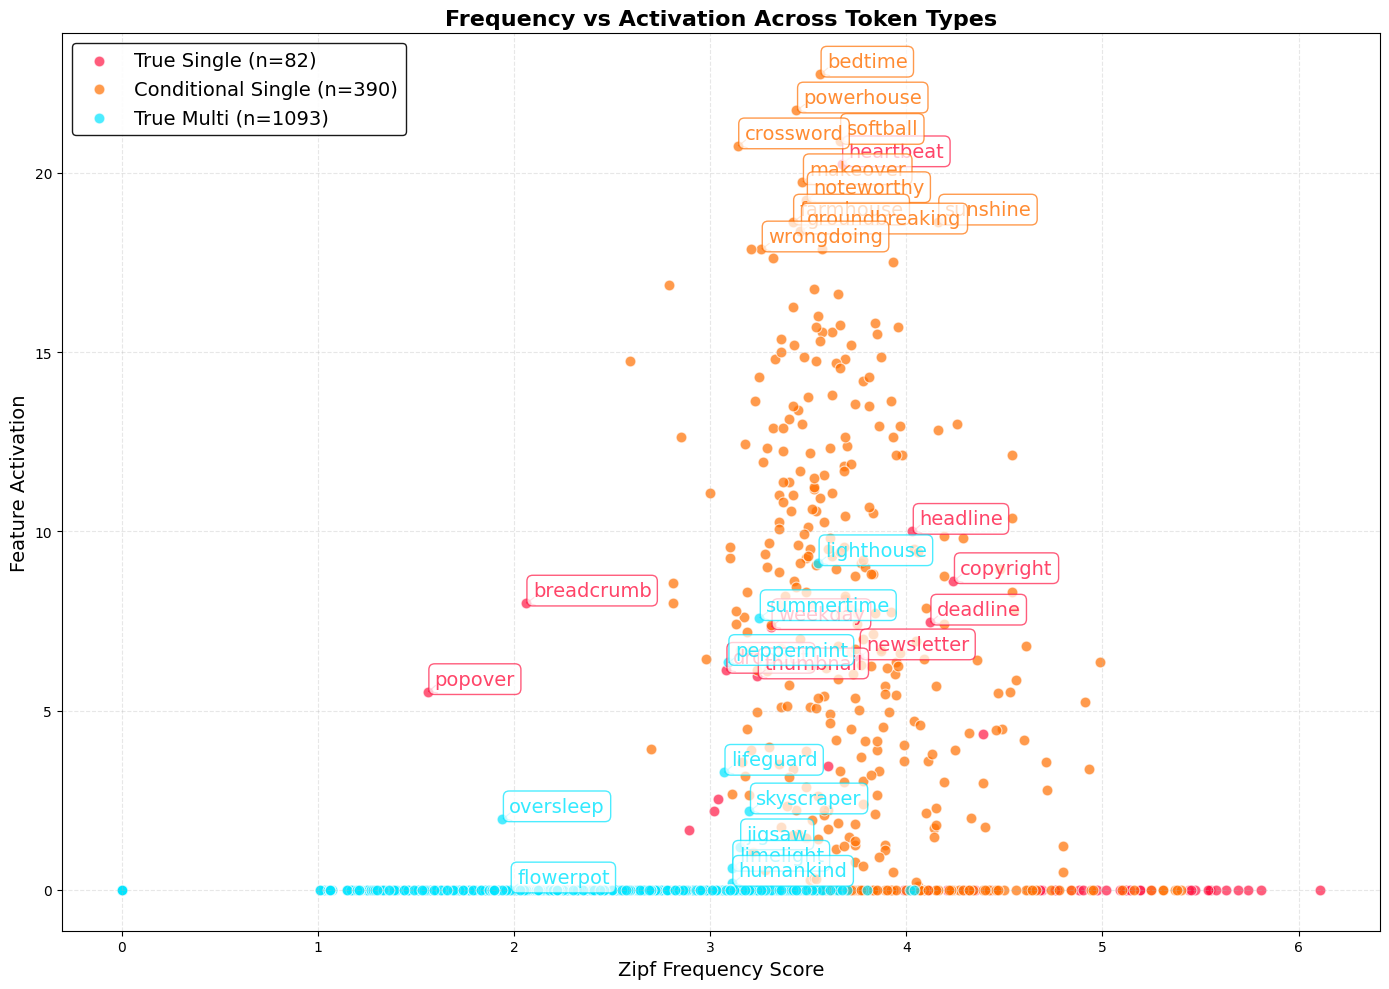

In [ ]:
# build plot

correlations = plot_all_groups_with_outlier_labels(
    [activations_true_single_token_compounds,
     activations_conditional_single_token_compounds,
     activations_true_multi_token_compounds],
    [frequencies_true_single,
     frequencies_conditional_single,
     frequencies_true_multiple],
    ['True Single', 'Conditional Single', 'True Multi'],
    ['#FF1744', '#FF6F00', '#00E5FF']
 )

In [ ]:
# check how all the True Multi-Token outliers tokenized
outlier_words = [
    ' lighthouse', ' summertime', ' peppermint',
    ' lifeguard', ' skyscraper', ' oversleep',
    ' jigsaw', ' limelight', ' humankind'
]

print("True Multi-Token Outliers - Tokenization:")
for word in outlier_words:
    tokens = model.tokenizer.encode(word)
    decoded = [model.tokenizer.decode([t]) for t in tokens]

    # get the last token
    last_token = decoded[-1] if decoded else ""

    # convert list to string for printing
    decoded_str = str(decoded)

    print(f"{word:20s} - tokens: {decoded_str:40s} | measuring: '{last_token}'")

True Multi-Token Outliers - Tokenization:
 lighthouse          - tokens: [' l', 'ighthouse']                      | measuring: 'ighthouse'
 summertime          - tokens: [' summ', 'ertime']                      | measuring: 'ertime'
 peppermint          - tokens: [' pepp', 'ermint']                      | measuring: 'ermint'
 lifeguard           - tokens: [' lif', 'eguard']                       | measuring: 'eguard'
 skyscraper          - tokens: [' skys', 'craper']                      | measuring: 'craper'
 oversleep           - tokens: [' overs', 'leep']                       | measuring: 'leep'
 jigsaw              - tokens: [' j', 'igsaw']                          | measuring: 'igsaw'
 limelight           - tokens: [' lim', 'elight']                       | measuring: 'elight'
 humankind           - tokens: [' hum', 'ankind']                       | measuring: 'ankind'


##Capitalization Impact


In [ ]:
closed_compounds_capitalized = []

for compound in closed_compounds:
  capitalized_compound = compound.strip().capitalize()
  closed_compounds_capitalized.append(capitalized_compound)
print(len(closed_compounds_capitalized))
print(closed_compounds_capitalized[:10])

1566
['Flowerpot', 'Nevertheless', 'Snowfall', 'Aftereffect', 'Flyby', 'Newborn', 'Snowflake', 'Afternoon', 'Flyweight', 'Newcomer']


In [ ]:
single_token_compounds_c = []
multi_token_compounds_c = []

In [ ]:
# check tokenization
def check_tokenization(compounds, single_token_list_c, multi_token_list_c):
  for word in compounds:
    tokens = tokenizer.tokenize(word)
    if len(tokens) == 1:
      single_token_list_c.append(word)
    else:
      multi_token_list_c.append(word)
  return (single_token_list_c, multi_token_list_c)

In [ ]:
single_token_compounds_c, multi_token_compounds_c = check_tokenization(closed_compounds_capitalized, single_token_compounds_c, multi_token_compounds_c)

In [ ]:
print(len(single_token_compounds_c))
print(single_token_compounds_c[:10])

90
['Nevertheless', 'Newsletter', 'Airport', 'Football', 'Software', 'Another', 'Someone', 'Something', 'Anyone', 'Nobody']


In [ ]:
print(len(multi_token_compounds_c))
print(multi_token_compounds_c[:10])

1476
['Flowerpot', 'Snowfall', 'Aftereffect', 'Flyby', 'Newborn', 'Snowflake', 'Afternoon', 'Flyweight', 'Newcomer', 'Snowman']


In [ ]:
# add whitespace to compound
closed_compounds_whitespace_c = list(map(lambda x: ' ' + x, closed_compounds_capitalized))
print(len(closed_compounds_whitespace_c))
print(closed_compounds_whitespace_c[:10])

1566
[' Flowerpot', ' Nevertheless', ' Snowfall', ' Aftereffect', ' Flyby', ' Newborn', ' Snowflake', ' Afternoon', ' Flyweight', ' Newcomer']


In [ ]:
single_token_compounds_whitespace_c = []
multi_token_compounds_whitespace_c = []

In [ ]:
single_token_compounds_whitespace, multi_token_compounds_whitespace = check_tokenization(closed_compounds_whitespace_c, single_token_compounds_whitespace_c, multi_token_compounds_whitespace_c)

In [ ]:
print(len(single_token_compounds_whitespace_c))
print(single_token_compounds_whitespace_c[:10])

177
[' Nevertheless', ' Newsletter', ' Newspaper', ' Aircraft', ' Airport', ' Football', ' Software', ' Somebody', ' Nightmare', ' Another']


In [ ]:
print(len(multi_token_compounds_whitespace_c))
print(multi_token_compounds_whitespace_c[:10])

1389
[' Flowerpot', ' Snowfall', ' Aftereffect', ' Flyby', ' Newborn', ' Snowflake', ' Afternoon', ' Flyweight', ' Newcomer', ' Snowman']


In [ ]:
single_token_compounds_removed_c = []
multiple_token_compounds_removed_c = []

In [ ]:
single_token_compounds_removed_c = remove_whitespace(single_token_compounds_whitespace_c, single_token_compounds_whitespace_c)
print(len(single_token_compounds_removed_c))
print(single_token_compounds_removed_c[:10])

KeyboardInterrupt: 

In [ ]:
multi_token_compounds_removed_c = remove_whitespace (multi_token_compounds_whitespace_c, multi_token_compounds_whitespace_c)
print(len(multi_token_compounds_removed_c))
print(multi_token_compounds_removed_c[:10])